# Week 7 — State Space Models & the Kalman Filter

State space models separate the **observation equation** (what we see) from the **state equation** (what drives the system). The Kalman filter provides the optimal recursive estimator for the unobserved state.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Edinburgh palette
UOE_RED   = '#7A2318'
UOE_GOLD  = '#B8860B'
UOE_BLUE  = '#2a78d6'
UOE_GREY  = '#52514e'
COLOURS   = [UOE_RED, UOE_BLUE, UOE_GOLD, '#2ca02c', '#9467bd', '#e377c2']

mpl.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.prop_cycle': mpl.cycler(color=COLOURS),
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 12, 'axes.titlesize': 14,
    'font.size': 11, 'legend.fontsize': 10,
    'lines.linewidth': 2,
})
print("Plotting style set ✓")


Plotting style set ✓


## 7.1 The Linear Gaussian State Space Model

**State equation:** $\alpha_{t+1} = T \alpha_t + R \eta_t, \quad \eta_t \sim N(0, Q)$

**Observation equation:** $y_t = Z \alpha_t + \varepsilon_t, \quad \varepsilon_t \sim N(0, H)$

## 7.2 Local Level Model (Random Walk + Noise)

The simplest state space model:
$$y_t = \mu_t + \varepsilon_t, \quad \mu_{t+1} = \mu_t + \eta_t$$

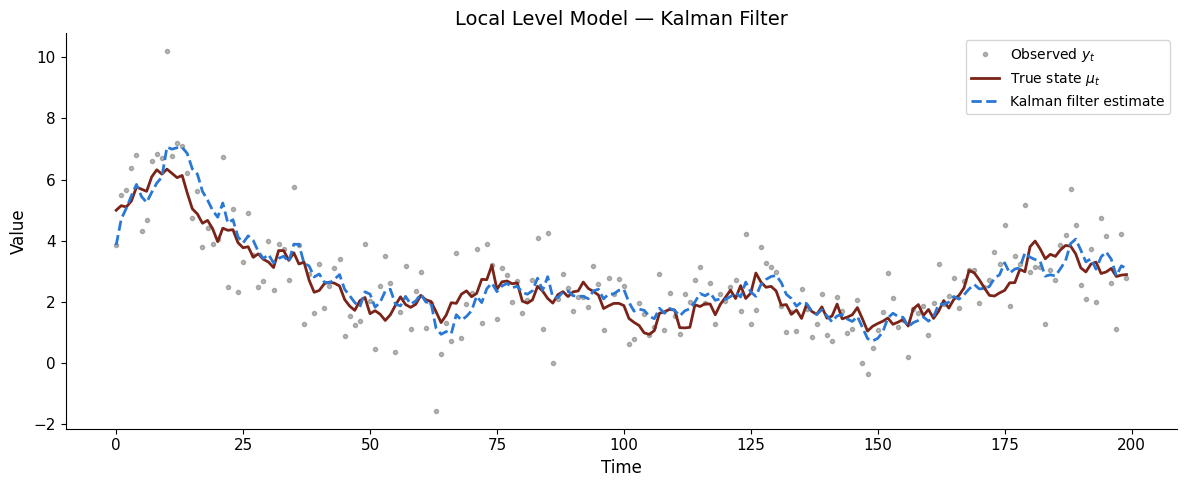

In [2]:
import statsmodels.api as sm

# Simulate local level model
np.random.seed(42)
T = 200
sigma_eta = 0.3  # state noise
sigma_eps = 1.0  # observation noise

mu = np.zeros(T)
y = np.zeros(T)
mu[0] = 5
for t in range(1, T):
    mu[t] = mu[t-1] + np.random.normal(0, sigma_eta)
y = mu + np.random.normal(0, sigma_eps, T)

# Estimate with Kalman filter
mod = sm.tsa.UnobservedComponents(y, level='local level')
res = mod.fit(disp=False)
filtered_state = res.filtered_state[0]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y, 'o', color=UOE_GREY, alpha=0.4, markersize=3, label='Observed $y_t$')
ax.plot(mu, color=UOE_RED, lw=2, label='True state $\\mu_t$')
ax.plot(filtered_state, '--', color=UOE_BLUE, lw=2, label='Kalman filter estimate')
ax.set_xlabel('Time')
ax.set_ylabel('Value')
ax.set_title('Local Level Model — Kalman Filter')
ax.legend()
plt.tight_layout()
plt.show()


## 7.3 Local Linear Trend Model

Adds a stochastic slope:
$$\mu_{t+1} = \mu_t + \nu_t + \eta_t, \quad \nu_{t+1} = \nu_t + \zeta_t$$

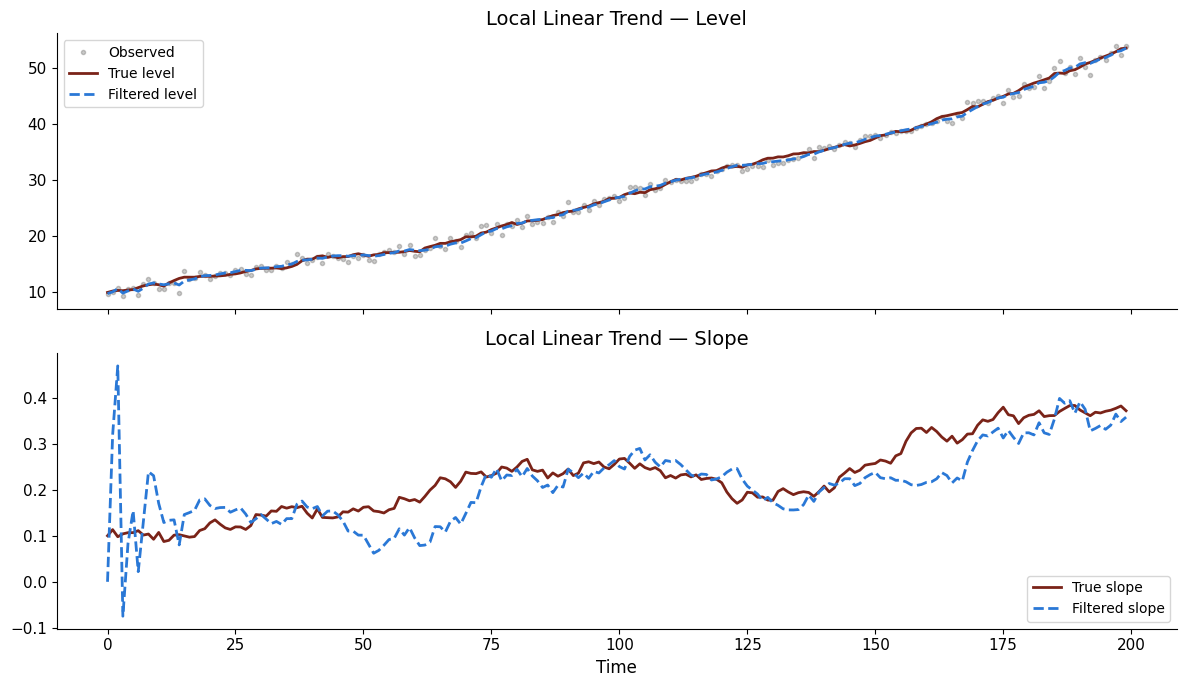

In [3]:
np.random.seed(10)
T = 200
mu2 = np.zeros(T)
nu = np.zeros(T)
mu2[0], nu[0] = 10, 0.1
for t in range(1, T):
    nu[t] = nu[t-1] + np.random.normal(0, 0.01)
    mu2[t] = mu2[t-1] + nu[t-1] + np.random.normal(0, 0.2)
y2 = mu2 + np.random.normal(0, 0.8, T)

mod2 = sm.tsa.UnobservedComponents(y2, level='local linear trend')
res2 = mod2.fit(disp=False)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(y2, 'o', color=UOE_GREY, alpha=0.3, markersize=3, label='Observed')
ax1.plot(mu2, color=UOE_RED, lw=2, label='True level')
ax1.plot(res2.filtered_state[0], '--', color=UOE_BLUE, lw=2, label='Filtered level')
ax1.set_title('Local Linear Trend — Level')
ax1.legend()

ax2.plot(nu, color=UOE_RED, lw=2, label='True slope')
ax2.plot(res2.filtered_state[1], '--', color=UOE_BLUE, lw=2, label='Filtered slope')
ax2.set_title('Local Linear Trend — Slope')
ax2.set_xlabel('Time')
ax2.legend()

plt.tight_layout()
plt.show()


## 7.4 Forecasting with State Space Models

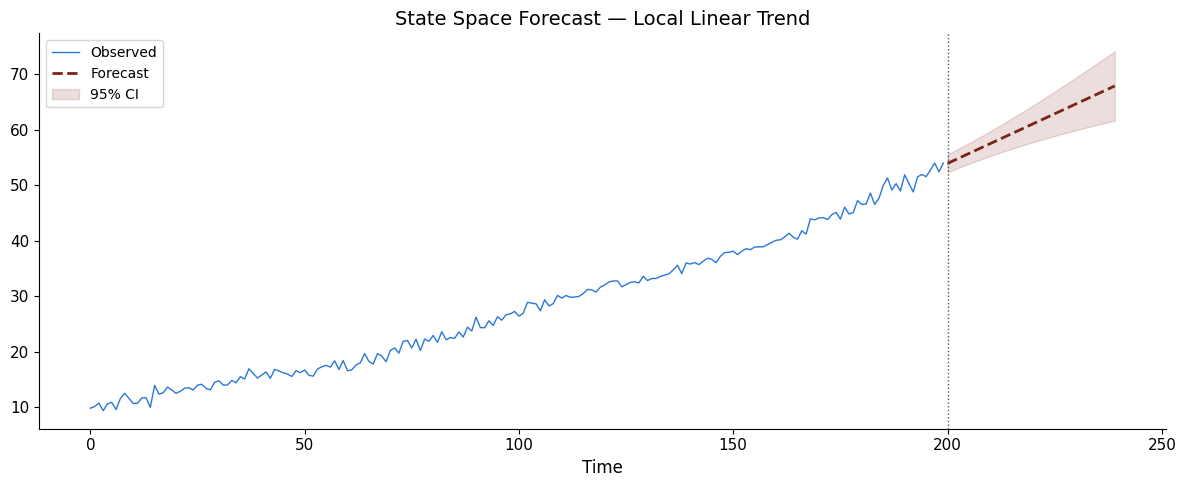

In [4]:
# Forecast from the local linear trend model
fc2 = res2.get_forecast(steps=40)
ci2 = fc2.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(T), y2, color=UOE_BLUE, lw=1, label='Observed')
ax.plot(range(T, T+40), fc2.predicted_mean, '--', color=UOE_RED, lw=2, label='Forecast')
ax.fill_between(range(T, T+40), ci2.values[:, 0] if hasattr(ci2, 'values') else ci2[:, 0], ci2.values[:, 1] if hasattr(ci2, 'values') else ci2[:, 1],
                alpha=0.15, color=UOE_RED, label='95% CI')
ax.axvline(T, ls=':', color=UOE_GREY, lw=1)
ax.set_title('State Space Forecast — Local Linear Trend')
ax.set_xlabel('Time')
ax.legend()
plt.tight_layout()
plt.show()


## Exercises

<details><summary>Exercise 1: Add a seasonal component to the state space model.</summary>

```python
mod_s = sm.tsa.UnobservedComponents(y_hw, level='local linear trend',
                                     seasonal=12)
res_s = mod_s.fit(disp=False)
res_s.plot_components(figsize=(12, 10))
plt.show()
```
</details>